In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [104]:
sns.set_palette(['#221f1f', '#b20710', '#e50914','#f5f5f1'])
sns.set_style("darkgrid")

In [105]:
df = pd.read_csv('netflix_titles.csv')

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [107]:
for i in df.columns:
    null_rate = df[i].isna().sum() / len(df) * 100
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

director null rate: 29.91%
cast null rate: 9.37%
country null rate: 9.44%
date_added null rate: 0.11%
rating null rate: 0.05%
duration null rate: 0.03%


In [108]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

df['cast'] = df['cast'].replace(np.nan, 'No Data')
df['director'] = df['director'].replace(np.nan, 'No Data')

df.dropna(inplace=True)

df.drop_duplicates(inplace= True)

In [109]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [110]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed')

df['month_date'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()
df['year_added'] = df['date_added'].dt.year
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_date,month_name,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021


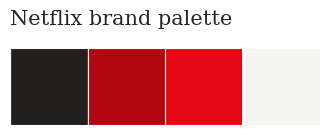

In [111]:
sns.palplot(['#221f1f', '#b20710', '#e50914','#f5f5f1'])
plt.title("Netflix brand palette ",loc='left',fontfamily='serif',fontsize=15,y=1.2)
plt.show()

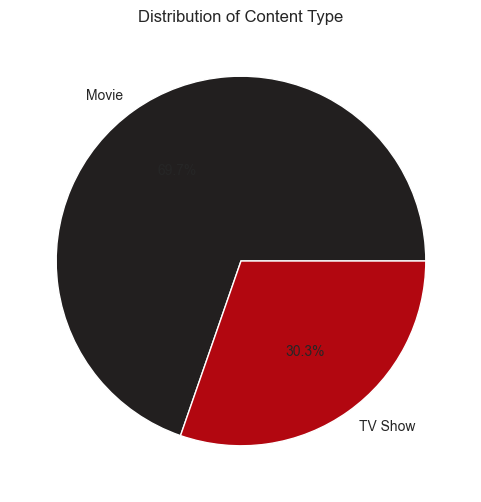

In [112]:
newDf = df.groupby(['type'])['type'].count()

plt.figure(figsize=(6,6))

plt.pie(
    newDf,
    labels=newDf.index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Content Type")
plt.show()

# Countries with the most Netflix Shows

In [113]:
df['first_country'] = df['country'].apply(lambda x : x.split(',')[0])
df['first_country'] = df['first_country'].replace('United States', 'USA')
df['first_country'] = df['first_country'].replace('United Kingdom', 'UK')
df['first_country'] = df['first_country'].replace('South Korea', 'S. Korea')

  first_country  type
0           USA  4031
1         India  1008
2            UK   627
3        Canada   271
4         Japan   257
5        France   212
6      S. Korea   211
7         Spain   181
8        Mexico   134
9     Australia   115


<Axes: xlabel='first_country', ylabel='type'>

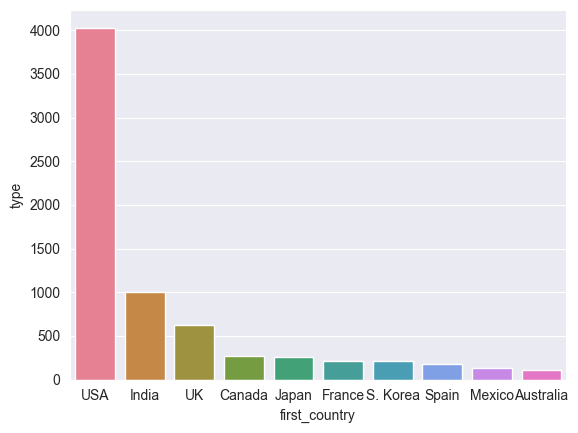

In [114]:
tv_counts = df.groupby('first_country')['type'].count().sort_values(ascending=False).reset_index()[:10]

print(tv_counts)

sns.barplot(
    x='first_country',
    data=tv_counts,
    y='type',
    hue='first_country'
)

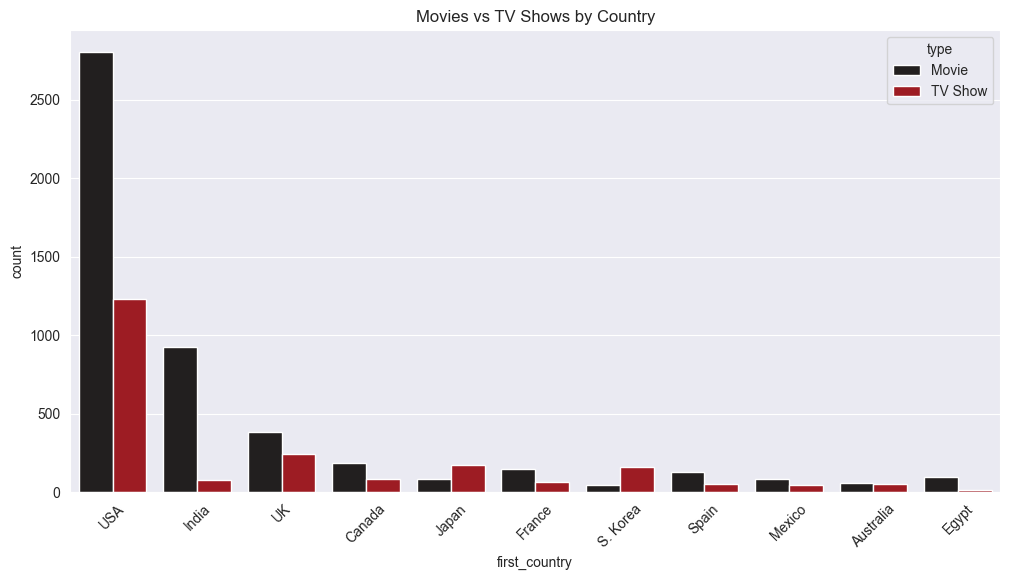

In [115]:
country_order = df['first_country'].value_counts()[:11].index
data_q2q3 = df[['type', 'first_country']].groupby('first_country')['type'].value_counts().unstack().loc[country_order]

# Reset index and melt
data_melt = data_q2q3.reset_index().melt(id_vars='first_country', value_name='count', var_name='type')


plt.figure(figsize=(12,6))
sns.barplot(
    data=data_melt,
    x='first_country',
    y='count',
    hue='type'
)
plt.xticks(rotation=45)
plt.title("Movies vs TV Shows by Country")
plt.show()

# Trend of movies

<Axes: xlabel='first_country', ylabel='Movie'>

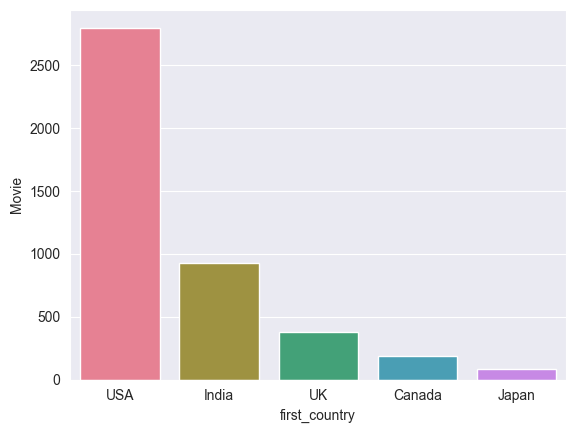

In [116]:
data = data_q2q3[:5].reset_index()
sns.barplot(
    data=data,
    y='Movie',
    x='first_country',
    hue='first_country'
)

# Trend of TV shows

<Axes: xlabel='first_country', ylabel='TV Show'>

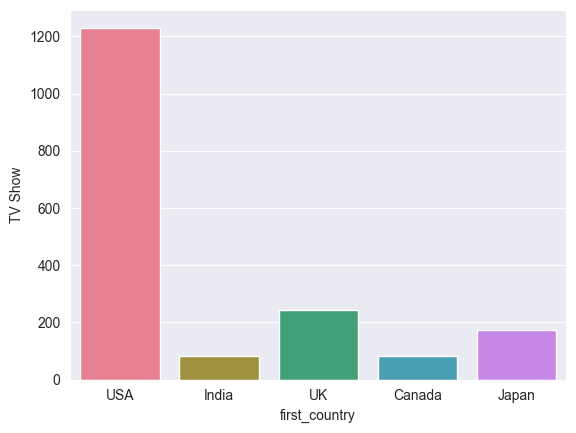

In [117]:
data = data_q2q3[:5].reset_index()
sns.barplot(
    data=data,
    y='TV Show',
    x='first_country',
    hue='first_country'
)

# TV Shows / Movies by Year since 2020

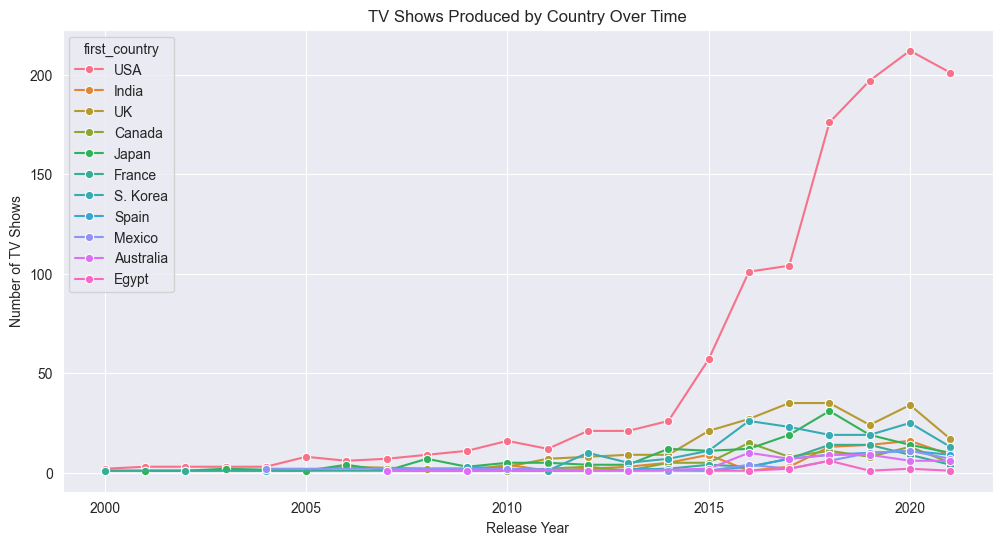

In [118]:
tv_shows_year = df[
    (df['type'] == 'TV Show') & (df['release_year'] >= 2000)
].groupby(['first_country', 'release_year']).size().loc[country_order].unstack()


tv_long = tv_shows_year.reset_index().melt(
    id_vars='first_country',
    var_name='release_year',
    value_name='count'
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=tv_long,
    x='release_year',
    y='count',
    hue='first_country',
    marker='o'
)

plt.title("TV Shows Produced by Country Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of TV Shows")

plt.show()

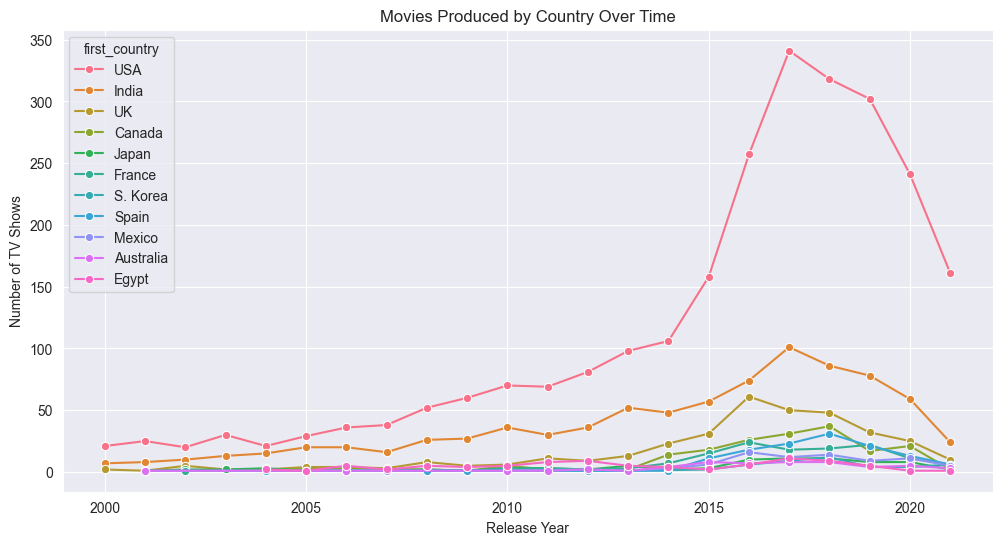

In [119]:
tv_shows_year = df[
    (df['type'] == 'Movie') & (df['release_year'] >= 2000)
].groupby(['first_country', 'release_year']).size().loc[country_order].unstack()


tv_long = tv_shows_year.reset_index().melt(
    id_vars='first_country',
    var_name='release_year',
    value_name='count'
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=tv_long,
    x='release_year',
    y='count',
    hue='first_country',
    marker='o'
)

plt.title("Movies Produced by Country Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of TV Shows")

plt.show()

# Month Stuff

In [120]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_date,month_name,year_added,first_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,September,2021,USA
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,September,2021,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,September,2021,USA
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,September,2021,USA
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,September,2021,India


# Trend of TV shows and Movies over the year

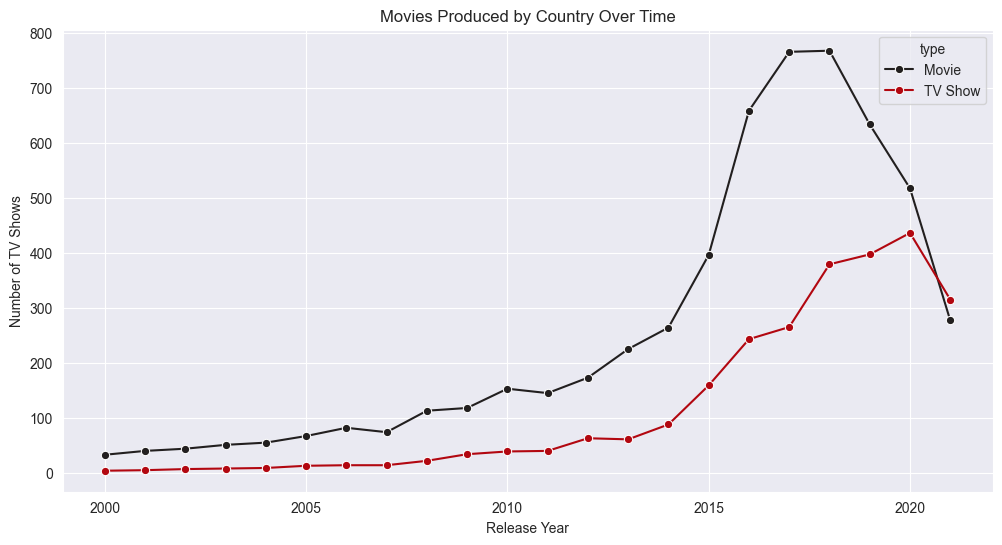

In [121]:
tv_shows_year = df[
    df['release_year'] >= 2000
].groupby(['release_year','type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))

sns.lineplot(
    data=tv_shows_year,
    x='release_year',
    y='count',
    marker='o',
    hue='type'
)

plt.title("Movies Produced by Country Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of TV Shows")

plt.show()

# Trend by months

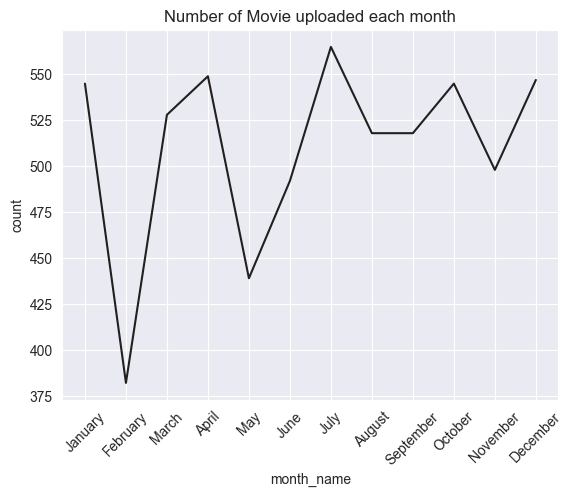

In [122]:
import calendar

month_order = list(calendar.month_name[1:])

df['month_name'] = pd.Categorical(
    df['month_name'],
    categories=month_order,
    ordered=True
)
movies_monthly = (
    df[df['type'] == 'Movie']
    .groupby(['month_name','type'])
    .size()
    .reset_index(name='count')
    .sort_values('month_name')
)

sns.lineplot(
    data=movies_monthly,
    x='month_name',
    y='count'
)
plt.title("Number of Movie uploaded each month")
plt.xticks(rotation=45)
plt.show()

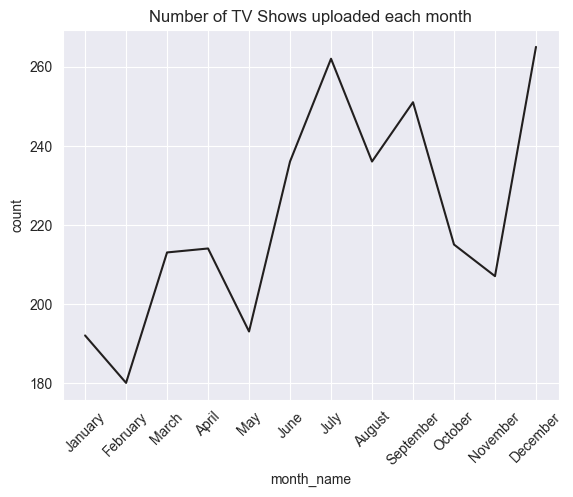

In [123]:
month_order = list(calendar.month_name[1:])

df['month_name'] = pd.Categorical(
    df['month_name'],
    categories=month_order,
    ordered=True
)
movies_monthly = (
    df[df['type'] == 'TV Show']
    .groupby(['month_name','type'])
    .size()
    .reset_index(name='count')
    .sort_values('month_name')
)

sns.lineplot(
    data=movies_monthly,
    x='month_name',
    y='count'
)
plt.title("Number of TV Shows uploaded each month")
plt.xticks(rotation=45)
plt.show()

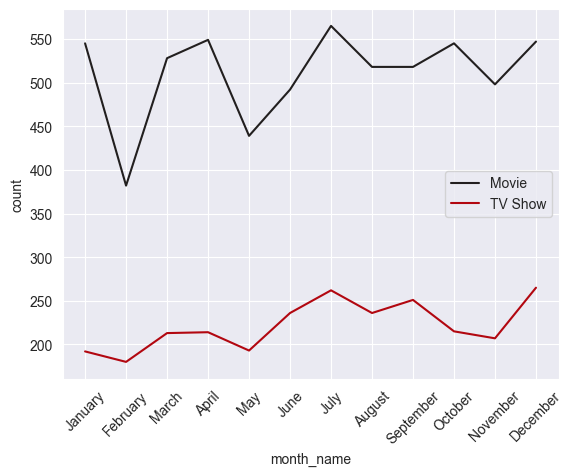

In [124]:
type_monthly = (
    df.groupby(['month_name','type'])
    .size()
    .reset_index(name='count')
    .sort_values('month_name')
)

sns.lineplot(
    data=type_monthly,
    x='month_name',
    y='count',
    hue='type'
)
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Rating Stuff

In [125]:
ratings_ages = {
    'TV-PG': 'Older Kids',
    'TV-MA': 'Adults',
    'TV-Y7-FV': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-14': 'Teens',
    'R': 'Adults',
    'TV-Y': 'Kids',
    'NR': 'Adults',
    'PG-13': 'Teens',
    'TV-G': 'Kids',
    'PG': 'Older Kids',
    'G': 'Kids',
    'UR': 'Adults',
    'NC-17': 'Adults'
}

df['target_ages'] = df['rating'].replace(ratings_ages)

df['genre'] = df['listed_in'].apply(lambda x :  x.replace(' ,',',').replace(', ',',').split(','))

# Number of films by target ages

<Axes: xlabel='target_ages', ylabel='count'>

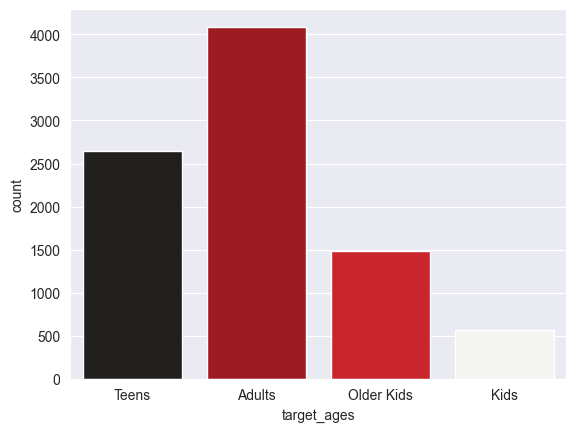

In [126]:
sns.countplot(
    data=df,
    x='target_ages',
    hue='target_ages'
)

# Number of adult shows by country

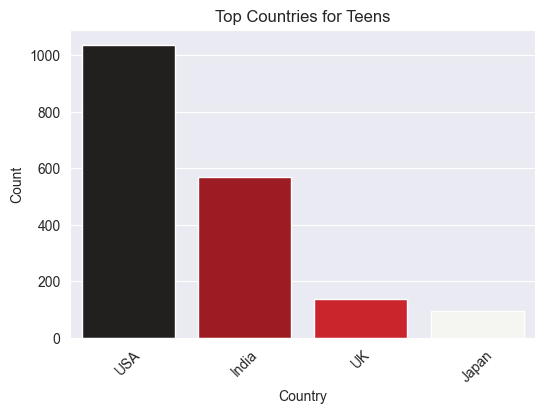

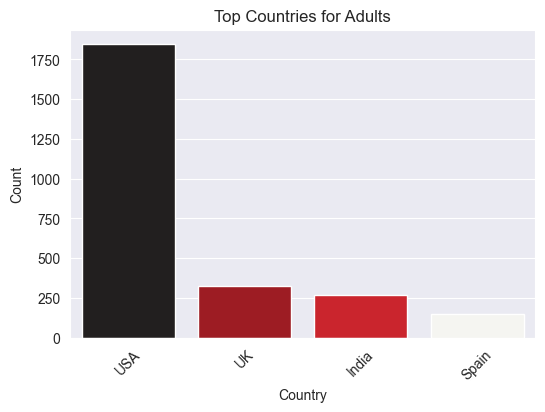

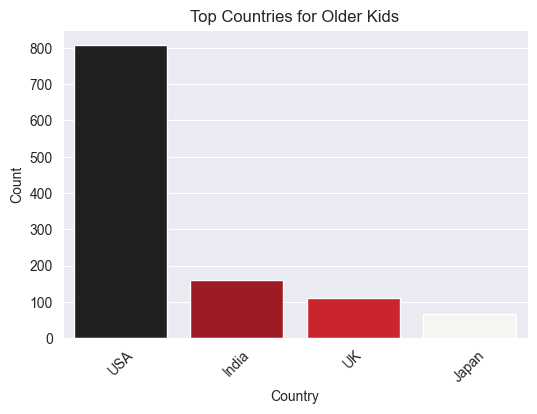

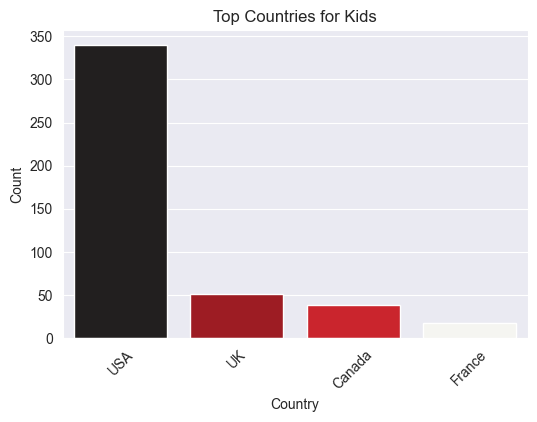

In [131]:
for item in df['target_ages'].dropna().unique():
    
    adult_shows_by_country = (
        df[df['target_ages'] == item]
        .groupby('first_country')
        .size()
        .reset_index(name='count')
        .sort_values(by='count', ascending=False)[:4]
    )

    plt.figure(figsize=(6,4))  # new plot each iteration

    sns.barplot(
        data=adult_shows_by_country,
        x='first_country',
        y='count',
        hue='first_country'
    )

    plt.title(f"Top Countries for {item}")
    plt.xlabel("Country")
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

# Trend of all the target ages

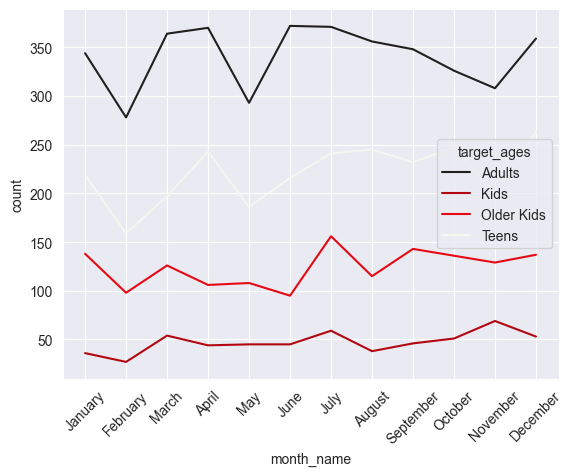

In [141]:
trend_year = df.groupby(['month_name','target_ages']).size().reset_index(name='count')

sns.lineplot(
    data=trend_year,
    x='month_name',
    y='count',
    hue='target_ages',
)

plt.xticks(rotation=45)

plt.show()

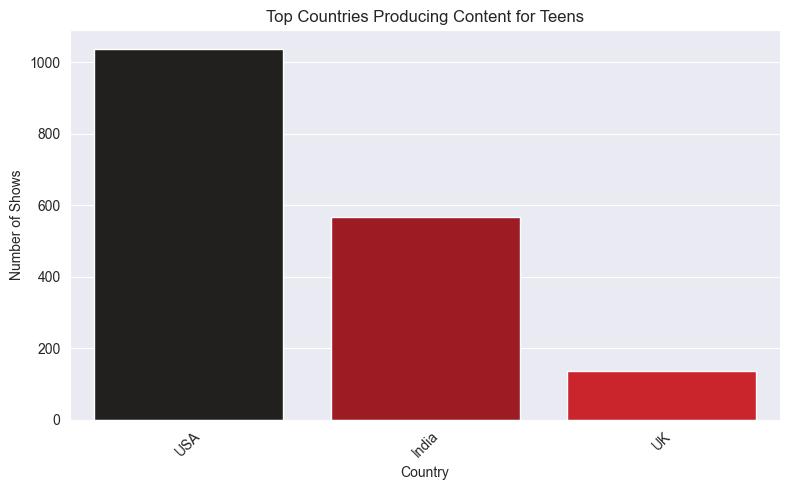

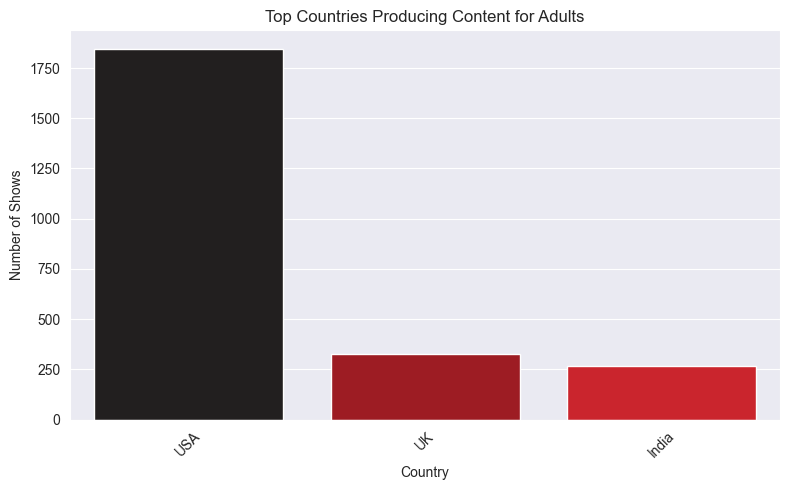

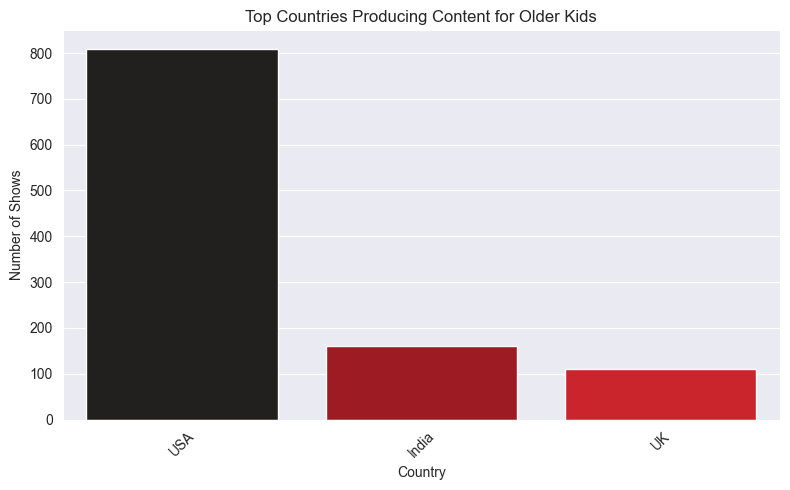

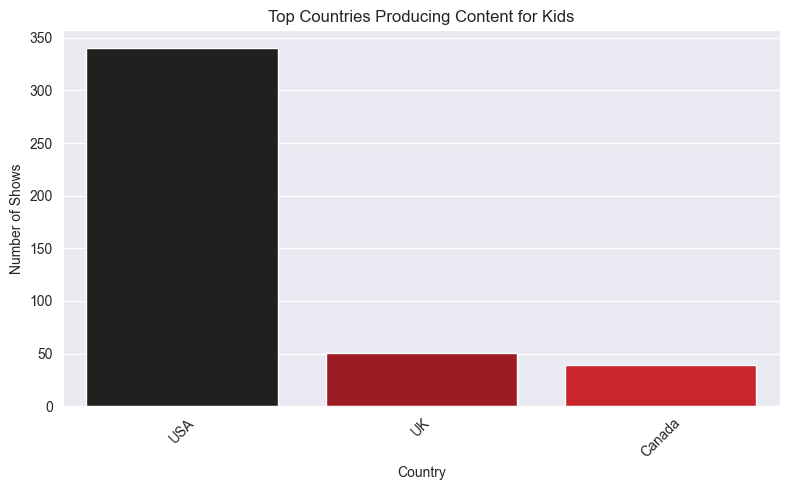

In [ ]:
# Remove rows where target_ages is missing
df_clean = df.dropna(subset=['target_ages', 'first_country'])

# Loop through each target age group
for age_group in df_clean['target_ages'].unique():

    # Filter dataset
    data = df_clean[df_clean['target_ages'] == age_group]

    # Count shows per country
    shows_by_country = (
        data.groupby('first_country')
        .size()
        .reset_index(name='count')
        .sort_values(by='count', ascending=False)
        .head(3)
    )

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=shows_by_country,
        x='first_country',
        y='count',
        hue='first_country',
        legend=False
    )

    plt.title(f"Top Countries Producing Content for {age_group}")
    plt.xlabel("Country")
    plt.ylabel("Number of Shows")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()